<a href="https://colab.research.google.com/github/RasinduHansaka/Labs_DL/blob/Lab02/MLP_with_MNIST_dataset.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from tensorflow.keras.datasets import mnist
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense,Flatten
from tensorflow.keras.utils import to_categorical
from matplotlib import pyplot as plt
import numpy as np


Load the MNIST dataset

In [ ]:
(train_data,train_target),(test_data,test_target) = mnist.load_data()

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


Visualize the dataset

Target labels:  [1 5 6 8 9 4 6 1 4 5]


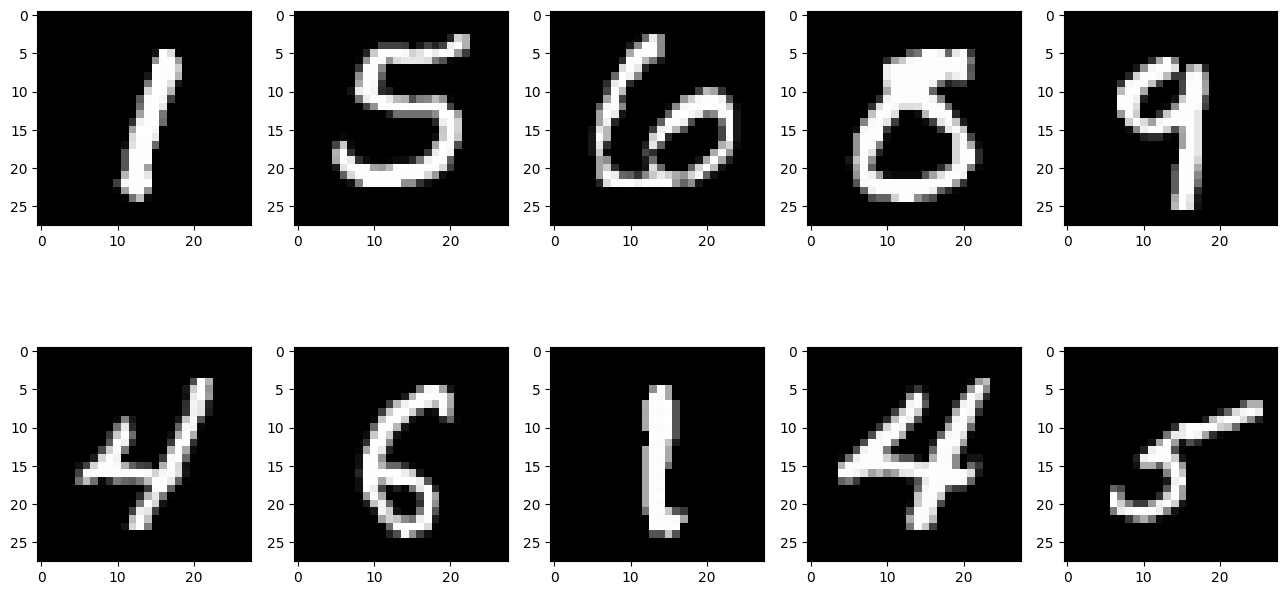

In [ ]:
fig, axs = plt.subplots(2, 5, figsize=(16,8))
random_numbers = np.random.randint(0, 60000, 10)
print('Target labels: ',train_target[random_numbers])
for idx, ax in enumerate(axs.ravel()):
    ax.imshow(train_data[random_numbers[idx]],cmap='gray')
plt.show()

Pre-processing stage

In [ ]:
new_train_data = train_data/255.0
new_test_data=test_data/255.0

new_train_target = to_categorical(train_target)
new_test_target = to_categorical(test_target)

Create the Model architecture

In [ ]:
model=Sequential()

model.add(Flatten(input_shape=(28,28)))

model.add(Dense(64,activation='relu'))
model.add(Dense(64,input_dim=64,activation='relu'))
model.add(Dense(32,input_dim=64,activation='relu'))
model.add(Dense(10,input_dim=32,activation='softmax'))
model.compile(loss='categorical_crossentropy',optimizer='adam',metrics=['accuracy'])

/usr/local/lib/python3.11/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)
/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │        50,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │           330 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 56,810 (221.91 KB)

 Trainable params: 56,810 (221.91 KB)

 Non-trainable params: 0 (0.00 B)

Train the model

In [ ]:
train_info = model.fit(new_train_data , new_train_target , epochs = 10)

Epoch 1/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 2ms/step - accuracy: 0.8435 - loss: 0.4938
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9594 - loss: 0.1360
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9728 - loss: 0.0897
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9783 - loss: 0.0725
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9798 - loss: 0.0618
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 3ms/step - accuracy: 0.9840 - loss: 0.0520
Epoch 7/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 2ms/step - accuracy: 0.9861 - loss: 0.0446
Epoch 8/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9886 - loss: 0.0346
Epoch 9/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 3ms/step - accuracy: 0.9903 - loss: 0.0298
Epoch 10/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 2ms/step - accuracy: 0.9910 - loss: 0.0276


Plot the loss and accuracy graphs

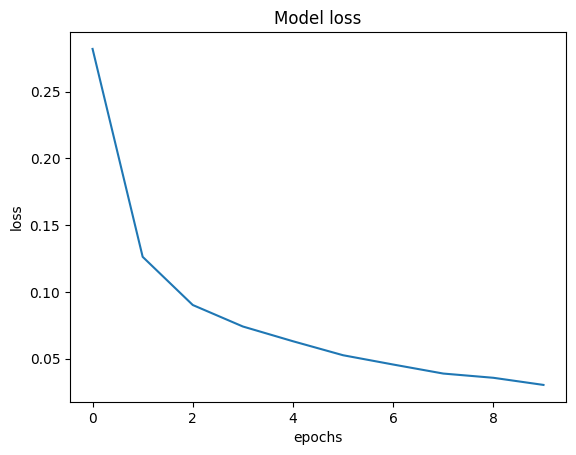

In [ ]:
plt.plot(train_info.history['loss'])
plt.xlabel('epochs')
plt.ylabel('loss')
plt.title('Model loss')
plt.show()

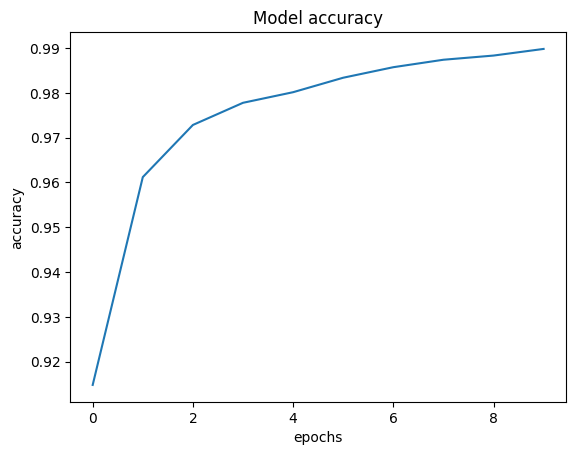

In [ ]:
plt.plot(train_info.history['accuracy'])
plt.xlabel('epochs')
plt.ylabel('accuracy')
plt.title('Model accuracy')
plt.show()

Test the performance of Model

In [ ]:
loss, acc = model.evaluate(new_test_data , new_test_target)
print(f'Loss of the Test dataset is: {loss}\nAccuracy of the test dataset is: {acc}')

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9717 - loss: 0.1126
Loss of the Test dataset is: 0.09793504327535629
Accuracy of the test dataset is: 0.9753999710083008


Save the model weights

In [ ]:
model.save_weights('MNIST_WEIGHTS_V1.weights.h5')

In [ ]:
# Baseline model (simple MLP as reference)
baseline = Sequential()
baseline.add(Flatten(input_shape=(28,28)))
baseline.add(Dense(128, activation="relu"))
baseline.add(Dense(10, activation="softmax"))

baseline.compile(optimizer="adam",
                 loss="sparse_categorical_crossentropy",
                 metrics=["accuracy"])

baseline.fit(new_train_data, train_target, epochs=10, batch_size=128, verbose=2)
test_loss, test_acc = baseline.evaluate(new_test_data, test_target, verbose=0)
print("Baseline test accuracy:", round(test_acc*100, 2), "%")

Epoch 1/10
469/469 - 2s - 5ms/step - accuracy: 0.9011 - loss: 0.3571
Epoch 2/10
469/469 - 2s - 3ms/step - accuracy: 0.9532 - loss: 0.1644
Epoch 3/10
469/469 - 3s - 5ms/step - accuracy: 0.9659 - loss: 0.1186
Epoch 4/10
469/469 - 3s - 5ms/step - accuracy: 0.9734 - loss: 0.0914
Epoch 5/10
469/469 - 3s - 6ms/step - accuracy: 0.9791 - loss: 0.0727
Epoch 6/10
469/469 - 4s - 9ms/step - accuracy: 0.9827 - loss: 0.0602
Epoch 7/10
469/469 - 2s - 3ms/step - accuracy: 0.9851 - loss: 0.0508
Epoch 8/10
469/469 - 3s - 5ms/step - accuracy: 0.9880 - loss: 0.0417
Epoch 9/10
469/469 - 4s - 9ms/step - accuracy: 0.9896 - loss: 0.0362
Epoch 10/10
469/469 - 3s - 7ms/step - accuracy: 0.9913 - loss: 0.0307
Baseline test accuracy: 97.79 %


In [ ]:

# Try different hyperparameter configs
configs = [
    dict(units=128, layers=2, dropout=0.1),
    dict(units=256, layers=2, dropout=0.2),
    dict(units=512, layers=2, dropout=0.3),
]

best_acc, best_model, best_cfg = 0, None, None

for cfg in configs:
    model = Sequential()
    model.add(Flatten(input_shape=(28,28)))
    for _ in range(cfg["layers"]):
        model.add(Dense(cfg["units"], activation="relu"))
    if cfg["dropout"] > 0:
        from tensorflow.keras.layers import Dropout
        model.add(Dropout(cfg["dropout"]))
    model.add(Dense(10, activation="softmax"))

    model.compile(optimizer="adam",
                  loss="sparse_categorical_crossentropy",
                  metrics=["accuracy"])

    model.fit(new_train_data, train_target,
              validation_split=0.1, epochs=10, batch_size=128, verbose=0)

    acc = model.evaluate(new_test_data, test_target, verbose=0)[1]
    print(cfg, "-> test acc:", round(acc*100, 2), "%")

    if acc > best_acc:
        best_acc, best_model, best_cfg = acc, model, cfg

print("\nBest config:", best_cfg)
print("Best test accuracy:", round(best_acc*100, 2), "%")

{'units': 128, 'layers': 2, 'dropout': 0.1} -> test acc: 97.76 %
{'units': 256, 'layers': 2, 'dropout': 0.2} -> test acc: 97.94 %
{'units': 512, 'layers': 2, 'dropout': 0.3} -> test acc: 97.94 %

Best config: {'units': 256, 'layers': 2, 'dropout': 0.2}
Best test accuracy: 97.94 %


In [ ]:
from tensorflow.keras import regularizers

# L1
l1_model = Sequential([
    Flatten(input_shape=(28,28)),
    Dense(256, activation="relu", kernel_regularizer=regularizers.l1(1e-5)),
    Dense(10, activation="softmax")
])
l1_model.compile(optimizer="adam", loss="sparse_categorical_crossentropy", metrics=["accuracy"])
l1_model.fit(new_train_data, train_target, epochs=10, batch_size=128, verbose=0)
print("L1 test accuracy:", l1_model.evaluate(new_test_data, test_target, verbose=0)[1])

# L2
l2_model = Sequential([
    Flatten(input_shape=(28,28)),
    Dense(256, activation="relu", kernel_regularizer=regularizers.l2(1e-4)),
    Dense(10, activation="softmax")
])
l2_model.compile(optimizer="adam", loss="sparse_categorical_crossentropy", metrics=["accuracy"])
l2_model.fit(new_train_data, train_target, epochs=10, batch_size=128, verbose=0)
print("L2 test accuracy:", l2_model.evaluate(new_test_data, test_target, verbose=0)[1])

# L1+L2
l1l2_model = Sequential([
    Flatten(input_shape=(28,28)),
    Dense(256, activation="relu", kernel_regularizer=regularizers.l1_l2(1e-5,1e-4)),
    Dense(10, activation="softmax")
])
l1l2_model.compile(optimizer="adam", loss="sparse_categorical_crossentropy", metrics=["accuracy"])
l1l2_model.fit(new_train_data, train_target, epochs=10, batch_size=128, verbose=0)
print("L1+L2 test accuracy:", l1l2_model.evaluate(new_test_data, test_target, verbose=0)[1])

L1 test accuracy: 0.9807999730110168
L2 test accuracy: 0.9807000160217285
L1+L2 test accuracy: 0.9794999957084656


313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


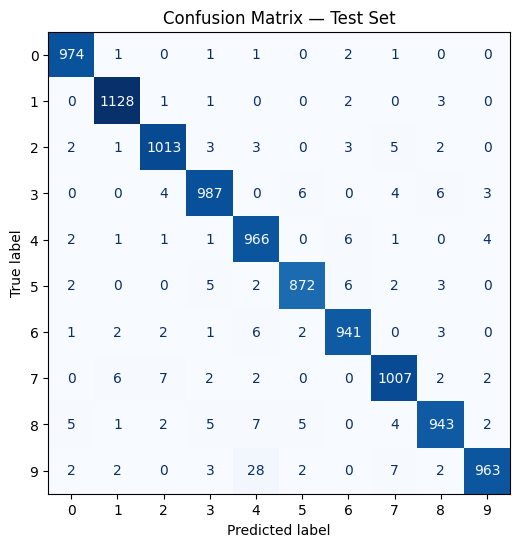


Classification report:

              precision    recall  f1-score   support

           0     0.9858    0.9939    0.9898       980
           1     0.9877    0.9938    0.9908      1135
           2     0.9835    0.9816    0.9825      1032
           3     0.9782    0.9772    0.9777      1010
           4     0.9517    0.9837    0.9675       982
           5     0.9831    0.9776    0.9803       892
           6     0.9802    0.9823    0.9812       958
           7     0.9767    0.9796    0.9781      1028
           8     0.9782    0.9682    0.9732       974
           9     0.9887    0.9544    0.9713      1009

    accuracy                         0.9794     10000
   macro avg     0.9794    0.9792    0.9792     10000
weighted avg     0.9795    0.9794    0.9794     10000



In [ ]:
import numpy as np
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report

# Use best_model from tuning
y_pred = np.argmax(best_model.predict(new_test_data), axis=1)

cm = confusion_matrix(test_target, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=range(10))

fig, ax = plt.subplots(figsize=(6,6))
disp.plot(ax=ax, cmap='Blues', values_format='d', colorbar=False)
plt.title("Confusion Matrix — Test Set")
plt.show()

print("\nClassification report:\n")
print(classification_report(test_target, y_pred, digits=4))